<a href="https://colab.research.google.com/github/Asritha0507/ML-Market-Basket-Analysis/blob/main/02_Data_Preparation_and_Exploratory_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2: Data Preparation and Exploratory Data Analysis

## Objective

This notebook prepares the raw Instacart Market Basket Analysis dataset for
subsequent feature engineering and machine learning.

The main objectives are:

1. Load the raw datasets efficiently.
2. Understand the structure and size of each dataset.
3. Analyze users, orders, products, and user-product interactions.
4. Examine the target variable `reordered`.
5. Identify data quality issues such as missing values and duplicates.
6. Analyze temporal ordering of customer purchases.
7. Prepare the data for leakage-safe feature engineering in later notebooks.

The project aims to develop a recommendation system capable of predicting
which products a customer is likely to reorder in their next shopping basket.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### 1. Import Required Libraries

The following libraries are used for data loading, manipulation, visualization,
statistical analysis, and memory-efficient processing.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

base_path = "/content/drive/MyDrive/ML_Market_Basket_Analysis/Datasets"

print("Dataset path:", base_path)

Mounted at /content/drive
Dataset path: /content/drive/MyDrive/ML_Market_Basket_Analysis/Datasets


### 2. Mount Google Drive and Define Dataset Path

The raw Instacart datasets are stored in Google Drive. A common base path is
defined so that all datasets can be accessed consistently throughout the project.

In [ ]:
os.listdir(base_path
)

['departments.csv',
 'orders.csv',
 'products.csv',
 'aisles.csv',
 'order_products_prior.csv',
 'order_products_train.csv',
 'Model_Outputs',
 'Features',
 'Candidate_Training_Data',
 'Engineered_Features',
 'Augmented_Candidate_Data_Corrected',
 'Augmented_Labeled_Candidates_Fixed',
 'Augmented_Training_Data',
 'Augmented_Candidate_Data',
 'Augmented_Labeled_Candidates']

###4. Understanding the Instacart Dataset

The Instacart dataset is relational rather than a single flat table.

The major tables represent:

- **Orders** — information about customer orders and their timing.
- **Order Products** — products contained in each order.
- **Products** — product-level information.
- **Aisles** — product aisle/category information.
- **Departments** — higher-level product department information.

The relationships between these tables allow us to reconstruct customer
shopping histories and product purchase sequences.

This structure is particularly useful for a next-basket recommendation system
because recommendations depend on the interaction between users, products,
and previous orders.

In [ ]:
orders = pd.read_csv(
    f"{base_path}/orders.csv",
    dtype={
        "order_id": "int32",
        "user_id": "int32",
        "order_number": "int16",
        "order_dow": "int8",
        "order_hour_of_day": "int8",
        "days_since_prior_order": "float32"
    }
)

orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


### 5. Load Orders Data

The orders table contains the chronological purchasing information required
to understand customer behavior.

Important variables include:

- `order_id` — unique order identifier.
- `user_id` — customer identifier.
- `order_number` — chronological order number for each customer.
- `order_dow` — day of the week on which the order was placed.
- `order_hour_of_day` — hour at which the order was placed.
- `days_since_prior_order` — number of days since the customer's previous order.
- `eval_set` — identifies the training, prior, and test portions of the original dataset.

Integer and floating-point columns are assigned memory-efficient data types
to make processing the large dataset more practical.

In [ ]:
print("Orders shape:", orders.shape)
print("Number of users:", orders["user_id"].nunique())
print("Number of orders:", orders["order_id"].nunique())

Orders shape: (3421083, 7)
Number of users: 206209
Number of orders: 3421083


### 6. Orders Dataset Size

The number of rows and columns is calculated to understand the scale of the
dataset before performing further processing.

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int32  
 1   user_id                 int32  
 2   eval_set                object 
 3   order_number            int16  
 4   order_dow               int8   
 5   order_hour_of_day       int8   
 6   days_since_prior_order  float32
dtypes: float32(1), int16(1), int32(2), int8(2), object(1)
memory usage: 78.3+ MB


### 6. Orders Dataset Size

The number of rows and columns is calculated to understand the scale of the
dataset before performing further processing.

In [ ]:
print(orders.isnull().sum())

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64


### 8. Missing Value Analysis

Missing values are examined before feature engineering.

In the Instacart dataset, `days_since_prior_order` may be missing for a
customer's first recorded order because there is no previous order from which
to calculate the time difference.

Such missing values should therefore not automatically be treated as errors.
Their meaning must be considered before deciding how to handle them.

In [ ]:
user_order_counts = (
    orders.groupby("user_id")["order_number"]
    .max()
)

print(user_order_counts.describe())

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_number, dtype: float64


### 9. Customer Order History

The number of orders placed by each customer is analyzed to understand the
distribution of customer activity.

This is important because recommendation quality can differ between users
with short purchase histories and users with extensive purchase histories.

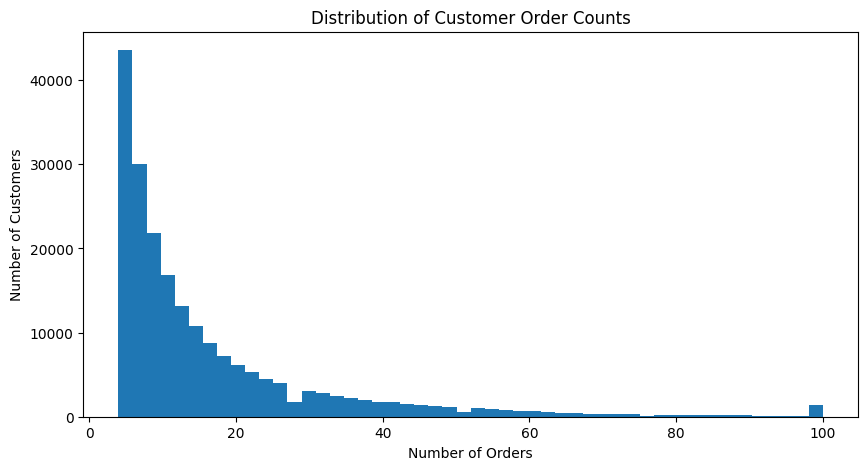

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    user_order_counts,
    bins=50
)

plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Order Counts")

plt.show()

### 10. Distribution of Customer Order Counts

The distribution of the number of orders per customer is visualized.

This helps identify whether the dataset contains mostly new/infrequent
customers or customers with substantial historical purchase behavior.

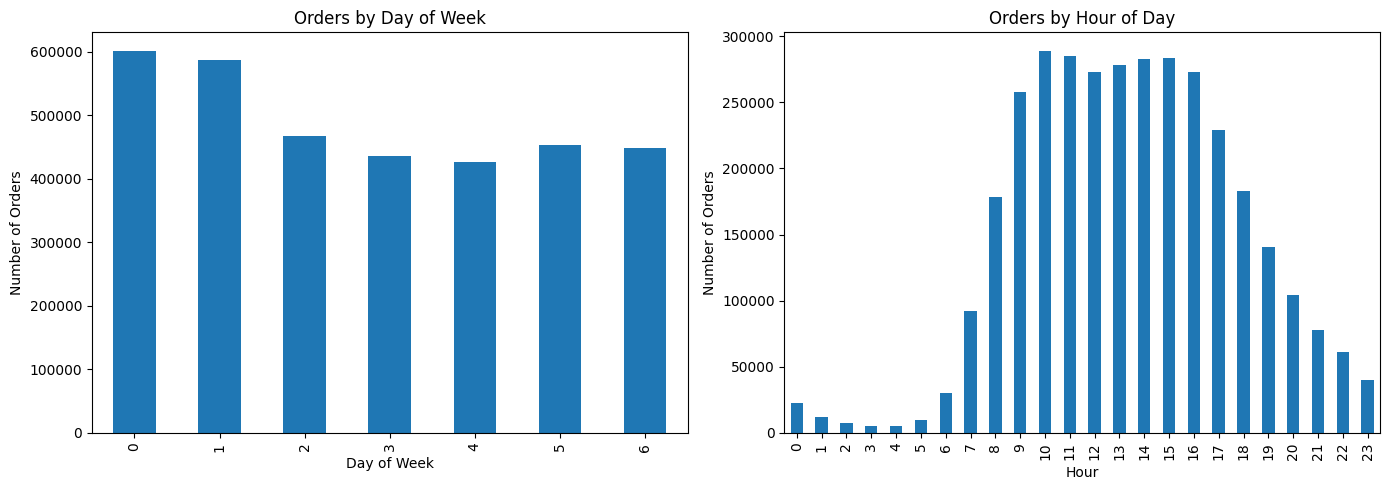

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orders["order_dow"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Orders by Day of Week")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Orders")

orders["order_hour_of_day"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Orders by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### 11. Customer Ordering Time Patterns

Customer ordering behavior is analyzed using:

- Day of week
- Hour of day

These temporal patterns may later be used as contextual features for
predicting the customer's next shopping basket.

In [ ]:
order_products_prior = pd.read_csv(
    f"{base_path}/order_products_prior.csv",
    usecols=[
        "order_id",
        "product_id",
        "add_to_cart_order",
        "reordered"
    ],
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int8",
        "reordered": "int8"
    }
)

order_products_prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


### 12. Load Historical Order-Product Interactions

The order-products table represents the products purchased in historical
orders.

This table is central to the recommendation problem because it provides the
actual user-product interactions from which purchase histories can be
constructed.

Only the columns required for the current analysis are loaded to reduce
memory consumption.

In [ ]:
print("Prior interactions shape:", order_products_prior.shape)

print(
    "Unique orders:",
    order_products_prior["order_id"].nunique()
)

print(
    "Unique products:",
    order_products_prior["product_id"].nunique()
)

Prior interactions shape: (32434489, 4)
Unique orders: 3214874
Unique products: 49677


### 13. Historical Interaction Dataset Size

The size of the historical user-product interaction table is examined.

Because this table contains millions of interactions, memory-efficient
processing and chunking strategies will be important in later stages of the
project.

In [ ]:
print(order_products_prior["reordered"].value_counts())

print("\nProportion:")
print(
    order_products_prior["reordered"]
    .value_counts(normalize=True)
)

reordered
1    19126536
0    13307953
Name: count, dtype: int64

Proportion:
reordered
1    0.589697
0    0.410303
Name: proportion, dtype: float64


### 14. Reorder Target Distribution

The `reordered` variable indicates whether a product in an order had been
purchased previously by the same customer.

It is the initial target for the reorder prediction component of the project.

Understanding the class distribution is important because an imbalanced target
can make accuracy alone an unreliable evaluation metric.

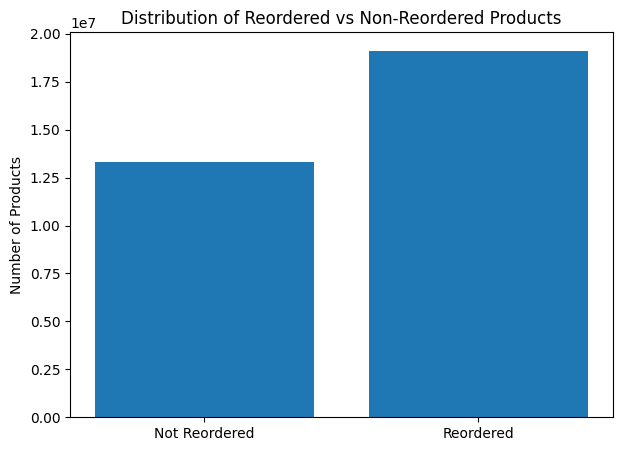

In [ ]:
reorder_counts = order_products_prior["reordered"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Not Reordered", "Reordered"],
    [
        reorder_counts.get(0, 0),
        reorder_counts.get(1, 0)
    ]
)

plt.ylabel("Number of Products")
plt.title("Distribution of Reordered vs Non-Reordered Products")

plt.show()

### 15. Visualization of Reorder Distribution

The proportion of reordered and non-reordered products is visualized to
understand the class balance of the prediction problem.

In [ ]:
product_counts = (
    order_products_prior
    .groupby("product_id")
    .size()
    .sort_values(ascending=False)
)

print(product_counts.describe())
print(product_counts.head(10))

count     49677.000000
mean        652.907563
std        4792.114416
min           1.000000
25%          17.000000
50%          60.000000
75%         260.000000
max      472565.000000
dtype: float64
product_id
24852    472565
13176    379450
21137    264683
21903    241921
47209    213584
47766    176815
47626    152657
16797    142951
26209    140627
27845    137905
dtype: int64


### 16. Product Popularity Analysis

Product purchase frequencies are calculated to identify highly popular
products.

Product popularity is useful for recommendation systems because frequently
purchased products can provide strong baseline recommendation signals.

However, popularity will later be calculated using only historical information
available before the prediction point to prevent data leakage.

### 17. User-Product Interaction History

A recommendation system must capture not only overall user behavior and
overall product popularity, but also the relationship between a specific
customer and a specific product.

For example, two customers may have the same total number of orders, but one
customer may repeatedly purchase a particular product while the other has
never purchased it.

Therefore, user-product interaction history will be used to construct
features such as:

- Number of previous purchases
- Recency of previous purchase
- Purchase frequency
- Number of orders since previous purchase
- Whether the product was purchased in the most recent basket

These features will form the basis of the recommendation model.

In [ ]:
print(
    "Duplicate interaction rows:",
    order_products_prior.duplicated().sum()
)

Duplicate interaction rows: 0


### 18. Duplicate Interaction Analysis

Duplicate rows are examined to determine whether they represent accidental
duplication or legitimate repeated product entries within orders.

This distinction is important because removing valid interactions could
incorrectly change customer purchase histories.

In [ ]:
del product_counts
gc.collect()

8186

### 19. Memory Management

The Instacart dataset contains millions of records. Large intermediate
DataFrames can consume substantial memory during feature engineering.

Objects that are no longer required are therefore deleted and garbage
collection is triggered.

The original raw files remain unchanged; only the in-memory objects are
released.

### 20. Initial Data Observations

The exploratory analysis establishes several important characteristics of the
dataset:

1. The dataset contains a large number of customer orders and product
   interactions.
2. Customers have different numbers of historical orders.
3. Ordering behavior varies across hours and days.
4. Products have highly different purchase frequencies.
5. Reorder behavior is not perfectly balanced between the two classes.
6. User-product interaction history is essential for personalized
   recommendations.
7. The large interaction table motivates memory-efficient processing and
   chunk-based data processing in later notebooks.

These observations guide the feature engineering and modeling strategy used in
the next stages of the project.

## 21. Transition to Leakage-Safe Feature Engineering

The next notebook will construct historical features for the recommendation
system.

A critical requirement is **temporal leakage prevention**.

For every prediction instance, features must be calculated only from purchases
that occurred before the order being predicted.

For example, when predicting whether a customer will purchase a product in
order `n`:

- Orders `< n` may be used to construct historical features.
- Order `n` must not be used to construct the features.
- The actual products purchased in order `n` are used only as the target.

This temporal separation ensures that the machine learning model learns from
information that would genuinely have been available at prediction time.

The resulting pipeline will support both:

1. **Reorder prediction** — estimating whether a customer will purchase a
   previously purchased product again.

2. **Next-basket recommendation** — ranking candidate products according to
   their probability of appearing in the customer's next basket.

The next stage will therefore focus on constructing training examples from
customer purchase sequences rather than simply aggregating the complete
dataset.

In [ ]:
print(orders.shape)
print(order_products_prior.shape)
print(orders["user_id"].nunique())
print(order_products_prior["product_id"].nunique())
print(order_products_prior["reordered"].value_counts())
print(order_products_prior["reordered"].value_counts(normalize=True))

(3421083, 7)
(32434489, 4)
206209
49677
reordered
1    19126536
0    13307953
Name: count, dtype: int64
reordered
1    0.589697
0    0.410303
Name: proportion, dtype: float64
